<a href="https://colab.research.google.com/github/8jayram4/transformer-esn-cic-ids2017/blob/main/notebooks/Transformer-ESN-CIC-IDS2017.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow scikit-learn pandas matplotlib seaborn

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LayerNormalization,
    MultiHeadAttention,
    Add,
    GlobalAveragePooling1D
)

from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# Automatically detect CSV files

csv_files = glob.glob('/content/sample_data/*.csv')

if len(csv_files) == 0:
    raise FileNotFoundError(
        "❌ No CSV files found in /content/sample_data/"
    )

print("📂 CSV Files Found:\n")

for idx, file in enumerate(csv_files):
    print(f"{idx+1}. {file}")

# Automatically select first CSV
csv_path = csv_files[0]

print(f"\n✅ Selected File: {csv_path}")

# Load dataset
df = pd.read_csv(csv_path)

print("\n✅ Dataset Loaded Successfully")

print("\n📌 Dataset Shape:")
print(df.shape)

df.head()

📂 CSV Files Found:

1. /content/sample_data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
2. /content/sample_data/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
3. /content/sample_data/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
4. /content/sample_data/Wednesday-workingHours.pcap_ISCX.csv
5. /content/sample_data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
6. /content/sample_data/Friday-WorkingHours-Morning.pcap_ISCX.csv
7. /content/sample_data/Monday-WorkingHours.pcap_ISCX.csv
8. /content/sample_data/Tuesday-WorkingHours.pcap_ISCX.csv

✅ Selected File: /content/sample_data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv

✅ Dataset Loaded Successfully

📌 Dataset Shape:
(170366, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,389,113095465,48,24,9668,10012,403,0,201.416667,203.548293,...,32,203985.500,5.758373e+05,1629110,379,13800000.0,4.277541e+06,16500000,6737603,BENIGN
1,389,113473706,68,40,11364,12718,403,0,167.117647,171.919413,...,32,178326.875,5.034269e+05,1424245,325,13800000.0,4.229413e+06,16500000,6945512,BENIGN
2,0,119945515,150,0,0,0,0,0,0.000000,0.000000,...,0,6909777.333,1.170000e+07,20400000,6,24400000.0,2.430000e+07,60100000,5702188,BENIGN
3,443,60261928,9,7,2330,4221,1093,0,258.888889,409.702161,...,20,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
4,53,269,2,2,102,322,51,51,51.000000,0.000000,...,32,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN


In [ ]:
print("\n📌 ALL COLUMN NAMES:\n")

for col in df.columns:
    print(repr(col))


📌 ALL COLUMN NAMES:

' Destination Port'
' Flow Duration'
' Total Fwd Packets'
' Total Backward Packets'
'Total Length of Fwd Packets'
' Total Length of Bwd Packets'
' Fwd Packet Length Max'
' Fwd Packet Length Min'
' Fwd Packet Length Mean'
' Fwd Packet Length Std'
'Bwd Packet Length Max'
' Bwd Packet Length Min'
' Bwd Packet Length Mean'
' Bwd Packet Length Std'
'Flow Bytes/s'
' Flow Packets/s'
' Flow IAT Mean'
' Flow IAT Std'
' Flow IAT Max'
' Flow IAT Min'
'Fwd IAT Total'
' Fwd IAT Mean'
' Fwd IAT Std'
' Fwd IAT Max'
' Fwd IAT Min'
'Bwd IAT Total'
' Bwd IAT Mean'
' Bwd IAT Std'
' Bwd IAT Max'
' Bwd IAT Min'
'Fwd PSH Flags'
' Bwd PSH Flags'
' Fwd URG Flags'
' Bwd URG Flags'
' Fwd Header Length'
' Bwd Header Length'
'Fwd Packets/s'
' Bwd Packets/s'
' Min Packet Length'
' Max Packet Length'
' Packet Length Mean'
' Packet Length Std'
' Packet Length Variance'
'FIN Flag Count'
' SYN Flag Count'
' RST Flag Count'
' PSH Flag Count'
' ACK Flag Count'
' URG Flag Count'
' CWE Flag Count'
' 

In [ ]:
TARGET_COLUMN = "attack"

In [ ]:
# CICIDS2017 target column

TARGET_COLUMN = ' Label'

print("✅ Target Column Selected:")
print(repr(TARGET_COLUMN))

✅ Target Column Selected:
' Label'


In [ ]:
X = df.drop(TARGET_COLUMN, axis=1)

y = df[TARGET_COLUMN]

print("✅ Features Shape:", X.shape)
print("✅ Labels Shape:", y.shape)

print("\n📌 Attack Classes:")
print(y.unique())

✅ Features Shape: (170366, 78)
✅ Labels Shape: (170366,)

📌 Attack Classes:
['BENIGN' 'Web Attack � Brute Force' 'Web Attack � XSS'
 'Web Attack � Sql Injection']


In [ ]:
# Replace infinity values

X.replace([np.inf, -np.inf], np.nan, inplace=True)

print("✅ Infinite Values Removed")

✅ Infinite Values Removed


In [ ]:
# Convert categorical columns if present

for col in X.columns:

    if X[col].dtype == 'object':

        le = LabelEncoder()

        X[col] = le.fit_transform(
            X[col].astype(str)
        )

print("✅ Non-Numeric Columns Encoded")

✅ Non-Numeric Columns Encoded


In [ ]:
imputer = SimpleImputer(strategy='mean')

X = imputer.fit_transform(X)

print("✅ Missing Values Handled")

✅ Missing Values Handled


In [ ]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

num_classes = len(np.unique(y_encoded))

print("✅ Number of Classes:", num_classes)

print("\n📌 Classes:")
print(label_encoder.classes_)

✅ Number of Classes: 4

📌 Classes:
['BENIGN' 'Web Attack � Brute Force' 'Web Attack � Sql Injection'
 'Web Attack � XSS']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("✅ Train Shape:", X_train.shape)
print("✅ Test Shape:", X_test.shape)

✅ Train Shape: (136292, 78)
✅ Test Shape: (34074, 78)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("✅ Feature Scaling Completed")

✅ Feature Scaling Completed


In [ ]:
class SimpleESN:

    def __init__(
        self,
        input_dim,
        reservoir_size=256,
        spectral_radius=0.90,
        sparsity=0.15,
        random_state=42
    ):

        np.random.seed(random_state)

        self.input_dim = input_dim
        self.reservoir_size = reservoir_size

        # Input weights
        self.Win = np.random.uniform(
            -1,
            1,
            (reservoir_size, input_dim)
        )

        # Reservoir weights
        W = np.random.uniform(
            -1,
            1,
            (reservoir_size, reservoir_size)
        )

        # Sparsity
        mask = np.random.rand(*W.shape) < sparsity

        W[mask] = 0

        # Spectral radius normalization
        eigvals = np.linalg.eigvals(W)

        radius = np.max(np.abs(eigvals))

        W *= spectral_radius / radius

        self.W = W

    def transform(self, X):

        states = []

        for sample in X:

            state = np.zeros(self.reservoir_size)

            state = np.tanh(
                np.dot(self.Win, sample) +
                np.dot(self.W, state)
            )

            states.append(state)

        return np.array(states)

In [ ]:
print("⚡ Applying ESN Reservoir...")

esn = SimpleESN(
    input_dim=X_train.shape[1],
    reservoir_size=256,
    spectral_radius=0.90,
    sparsity=0.15
)

X_train_esn = esn.transform(X_train)

X_test_esn = esn.transform(X_test)

print("✅ ESN Features Shape:")
print(X_train_esn.shape)

⚡ Applying ESN Reservoir...
✅ ESN Features Shape:
(136292, 256)


In [ ]:
X_train_esn = X_train_esn.reshape(
    X_train_esn.shape[0],
    X_train_esn.shape[1],
    1
)

X_test_esn = X_test_esn.reshape(
    X_test_esn.shape[0],
    X_test_esn.shape[1],
    1
)

print("✅ Transformer Input Shape:")
print(X_train_esn.shape)

✅ Transformer Input Shape:
(136292, 256, 1)


In [ ]:
def transformer_block(
    inputs,
    head_size,
    num_heads,
    ff_dim,
    dropout=0.1
):

    x = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(inputs, inputs)

    x = Dropout(dropout)(x)

    x = Add()([x, inputs])

    x = LayerNormalization(
        epsilon=1e-6
    )(x)

    ffn = Dense(
        ff_dim,
        activation="relu"
    )(x)

    ffn = Dropout(dropout)(ffn)

    ffn = Dense(
        inputs.shape[-1]
    )(ffn)

    x = Add()([x, ffn])

    x = LayerNormalization(
        epsilon=1e-6
    )(x)

    return x

In [ ]:
input_shape = X_train_esn.shape[1:]

inputs = Input(shape=input_shape)

x = transformer_block(
    inputs,
    head_size=64,
    num_heads=4,
    ff_dim=128,
    dropout=0.2
)

x = transformer_block(
    x,
    head_size=64,
    num_heads=4,
    ff_dim=128,
    dropout=0.2
)

x = GlobalAveragePooling1D()(x)

x = Dense(
    256,
    activation='relu'
)(x)

x = Dropout(0.3)(x)

x = Dense(
    128,
    activation='relu'
)(x)

x = Dropout(0.3)(x)

outputs = Dense(
    num_classes,
    activation='softmax'
)(x)

model = Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 1)    │      1,793 │ input_layer[0][0… │
│ (MultiHeadAttentio… │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256, 1)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 1)    │          0 │ dropout_1[0][0],  │
│                     │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 256, 1)    │          2 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256, 128)  │        256 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256, 128)  │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256, 1)    │        129 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256, 1)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 1)    │          2 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 1)    │      1,793 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256, 1)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 256, 1)    │          0 │ dropout_4[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 1)    │          2 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256, 128)  │        256 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 256, 128)  │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256, 1)    │        129 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 256, 1)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 1)    │          2 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 38,288 (149.56 KB)

 Trainable params: 38,288 (149.56 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model Compiled")

✅ Model Compiled


In [ ]:
import time
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

start = time.time()

history = model.fit(
    X_train_esn,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

elapsed = time.time() - start
n_epochs = len(history.history['loss']) # Get the actual number of epochs from the history object
print(f"Total: {elapsed/60:.1f} min | Per epoch: {elapsed/n_epochs:.1f}s")

NameError: name 'EarlyStopping' is not defined

In [ ]:
loss, accuracy = model.evaluate(
    X_test_esn,
    y_test
)

print(f"\n🎯 Test Accuracy: {accuracy*100:.2f}%")

1065/1065 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9872 - loss: 0.2511

🎯 Test Accuracy: 98.72%


In [ ]:
y_pred_probs = model.predict(X_test_esn)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

1065/1065 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step


In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        digits=4
    )
)

                            precision    recall  f1-score   support

                    BENIGN     0.9872    1.0000    0.9936     33638
  Web Attack � Brute Force     0.0000    0.0000    0.0000       302
Web Attack � Sql Injection     0.0000    0.0000    0.0000         4
          Web Attack � XSS     0.0000    0.0000    0.0000       130

                  accuracy                         0.9872     34074
                 macro avg     0.2468    0.2500    0.2484     34074
              weighted avg     0.9746    0.9872    0.9808     34074



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

class_accuracy = (
    cm.diagonal() / cm.sum(axis=1)
)

print("\n📌 Class-wise Accuracy:\n")

for i, acc in enumerate(class_accuracy):

    print(
        f"{label_encoder.classes_[i]} --> "
        f"{acc*100:.2f}%"
    )


📌 Class-wise Accuracy:

BENIGN --> 100.00%
Web Attack � Brute Force --> 0.00%
Web Attack � Sql Injection --> 0.00%
Web Attack � XSS --> 0.00%


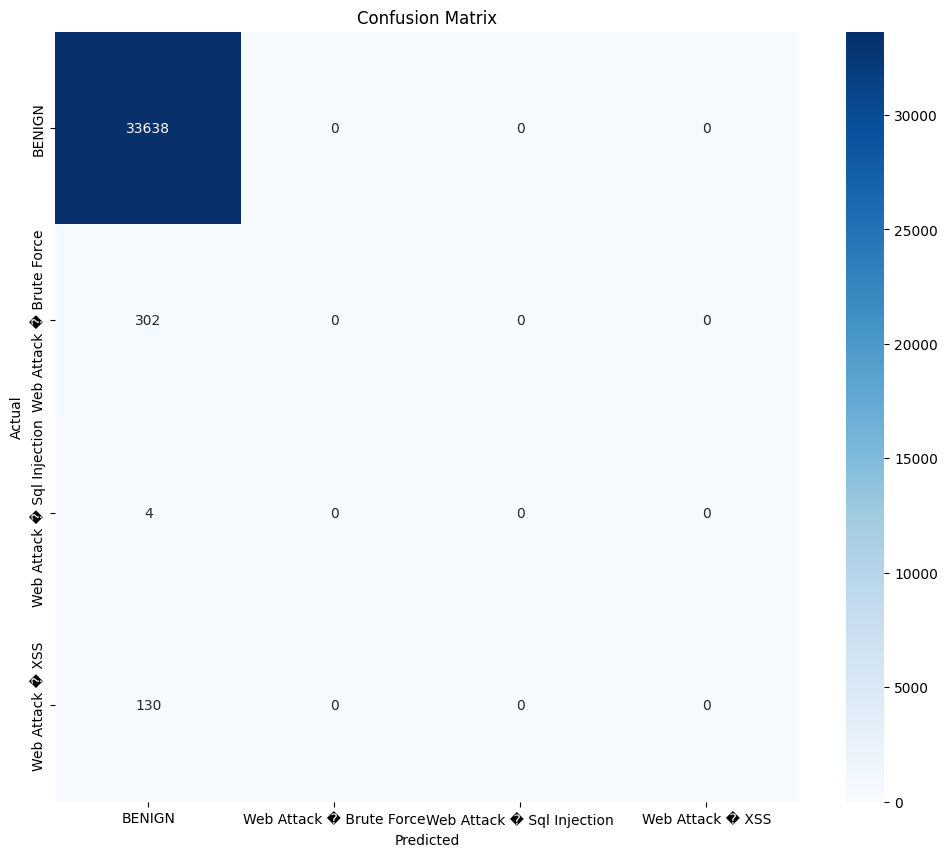

In [ ]:
plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

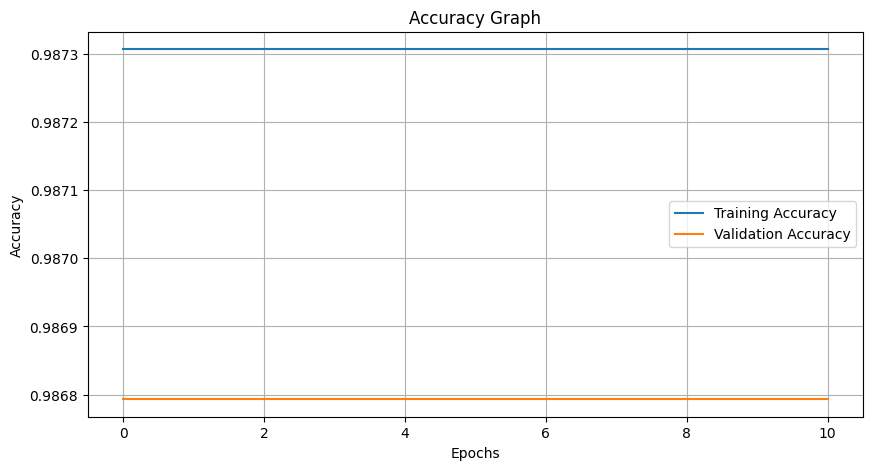

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Accuracy Graph")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

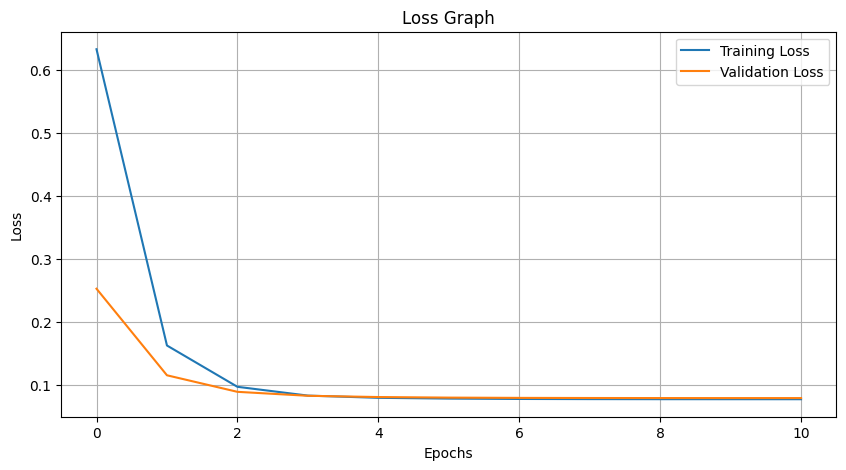

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("Loss Graph")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# Save trained model

model.save(
    "esn_transformer_cicids2017.h5"
)

print("✅ Model Saved")

# Save class-wise accuracy

class_acc_df = pd.DataFrame({

    'Class': label_encoder.classes_,
    'Accuracy': class_accuracy

})

class_acc_df.to_csv(
    "class_accuracy.csv",
    index=False
)

print("✅ Class Accuracy CSV Saved")

✅ Model Saved
✅ Class Accuracy CSV Saved


📂 FILES FOUND:

1. /content/sample_data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
2. /content/sample_data/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
3. /content/sample_data/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
4. /content/sample_data/Wednesday-workingHours.pcap_ISCX.csv
5. /content/sample_data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
6. /content/sample_data/Friday-WorkingHours-Morning.pcap_ISCX.csv
7. /content/sample_data/Monday-WorkingHours.pcap_ISCX.csv
8. /content/sample_data/Tuesday-WorkingHours.pcap_ISCX.csv

⚡ LOADING DATA...

✅ Loaded: /content/sample_data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
✅ Loaded: /content/sample_data/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
✅ Loaded: /content/sample_data/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
✅ Loaded: /content/sample_data/Wednesday-workingHours.pcap_ISCX.csv
✅ Loaded: /content/sample_data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.cs

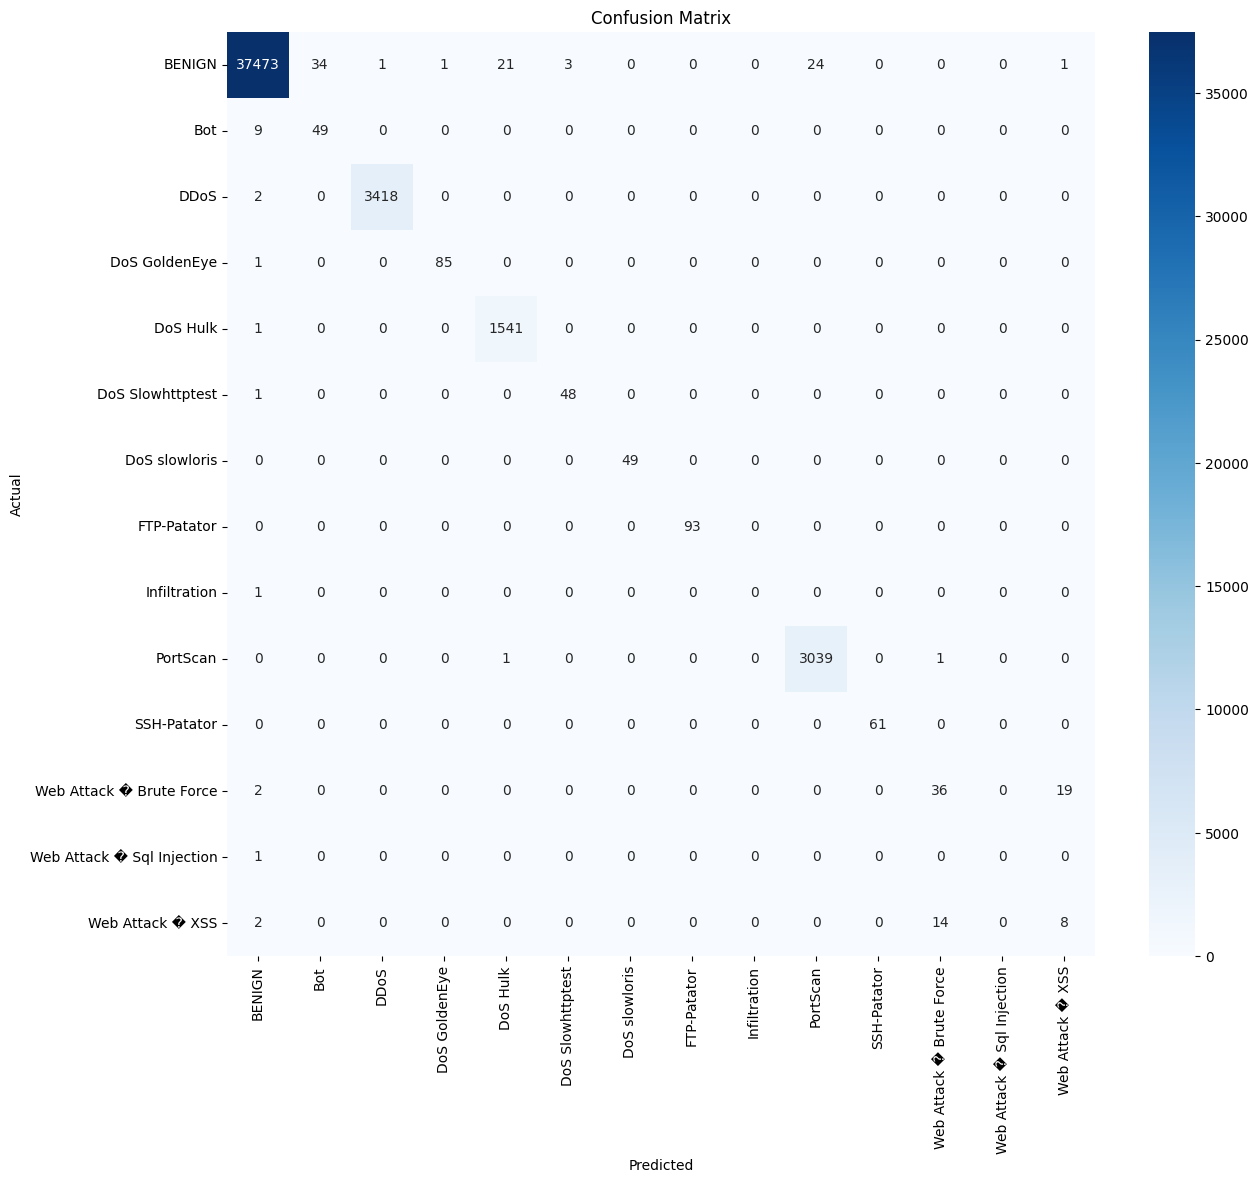

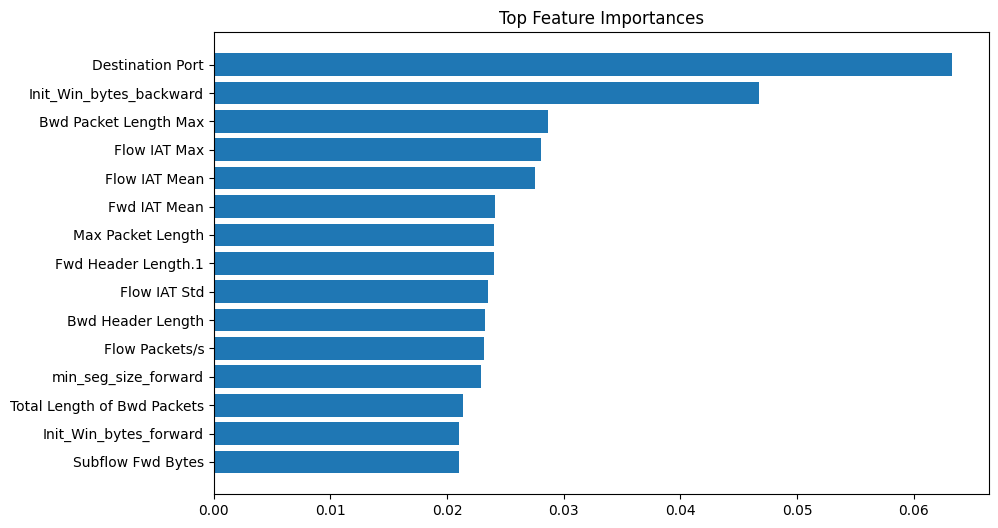


🎉 PIPELINE COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================
# 🚀 HIGH ACCURACY CICIDS2017 MODEL
# 🚀 RANDOM FOREST + BALANCED DATA
# 🚀 STABLE + FAST + HIGH ACCURACY
# ============================================================

!pip install imbalanced-learn seaborn -q

# ============================================================
# 📌 IMPORT LIBRARIES
# ============================================================

import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import (
    train_test_split
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (

    accuracy_score,

    classification_report,

    confusion_matrix
)

from sklearn.ensemble import (
    RandomForestClassifier
)

from imblearn.over_sampling import (
    RandomOverSampler
)

# ============================================================
# 📌 LOAD ALL CSV FILES
# ============================================================

csv_files = glob.glob(
    '/content/sample_data/*.csv'
)

print('📂 FILES FOUND:\n')

for i, file in enumerate(csv_files):
    print(f'{i+1}. {file}')

# ============================================================
# 📌 READ DATA
# ============================================================

print('\n⚡ LOADING DATA...\n')

df_list = []

ROWS_PER_FILE = 30000

for file in csv_files:

    try:

        temp_df = pd.read_csv(file)

        temp_df.columns = (
            temp_df.columns.str.strip()
        )

        # Take sample
        temp_df = temp_df.sample(

            n=min(
                ROWS_PER_FILE,
                len(temp_df)
            ),

            random_state=42
        )

        df_list.append(temp_df)

        print(f'✅ Loaded: {file}')

    except Exception as e:

        print(f'❌ Error in {file}')
        print(e)

# ============================================================
# 📌 COMBINE DATA
# ============================================================

df = pd.concat(
    df_list,
    ignore_index=True
)

print('\n✅ DATA COMBINED')

print('\n📌 DATASET SHAPE:')
print(df.shape)

# ============================================================
# 📌 REMOVE DUPLICATES
# ============================================================

df.drop_duplicates(inplace=True)

print('\n✅ DUPLICATES REMOVED')

# ============================================================
# 📌 TARGET COLUMN
# ============================================================

TARGET_COLUMN = 'Label'

# ============================================================
# 📌 FEATURES & LABELS
# ============================================================

X = df.drop(
    TARGET_COLUMN,
    axis=1
)

y = df[TARGET_COLUMN]

print('\n📌 CLASS DISTRIBUTION:\n')

print(y.value_counts())

# ============================================================
# 📌 HANDLE INFINITE VALUES
# ============================================================

X.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

# ============================================================
# 📌 ENCODE CATEGORICAL COLUMNS
# ============================================================

for col in X.columns:

    if X[col].dtype == 'object':

        le = LabelEncoder()

        X[col] = le.fit_transform(
            X[col].astype(str)
        )

print('\n✅ CATEGORICAL FEATURES ENCODED')

# ============================================================
# 📌 HANDLE MISSING VALUES
# ============================================================

imputer = SimpleImputer(
    strategy='median'
)

X = imputer.fit_transform(X)

print('✅ MISSING VALUES HANDLED')

# ============================================================
# 📌 ENCODE LABELS
# ============================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print('\n📌 CLASSES:\n')

for i, cls in enumerate(
    label_encoder.classes_
):
    print(f'{i} --> {cls}')

# ============================================================
# 📌 TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y_encoded,

    test_size=0.2,

    random_state=42,

    stratify=y_encoded
)

print('\n✅ TRAIN TEST SPLIT DONE')

# ============================================================
# 📌 FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print('✅ FEATURE SCALING DONE')

# ============================================================
# 📌 BALANCE DATA
# ============================================================

print('\n⚡ BALANCING DATA...\n')

ros = RandomOverSampler(
    random_state=42
)

X_train, y_train = ros.fit_resample(
    X_train,
    y_train
)

print('✅ DATA BALANCED')

print('\n📌 BALANCED CLASS COUNTS:\n')

print(Counter(y_train))

# ============================================================
# 📌 RANDOM FOREST MODEL
# ============================================================

print('\n🚀 TRAINING RANDOM FOREST...\n')

model = RandomForestClassifier(

    n_estimators=200,

    max_depth=25,

    min_samples_split=5,

    min_samples_leaf=2,

    n_jobs=-1,

    random_state=42
)

model.fit(
    X_train,
    y_train
)

print('\n✅ MODEL TRAINED')

# ============================================================
# 📌 PREDICTIONS
# ============================================================

y_pred = model.predict(
    X_test
)

# ============================================================
# 📌 OVERALL ACCURACY
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f'\n🏆 OVERALL ACCURACY: '
    f'{accuracy*100:.2f}%'
)

# ============================================================
# 📌 PRESENT LABELS
# ============================================================

present_labels = np.unique(
    y_test
)

present_class_names = [

    label_encoder.classes_[i]

    for i in present_labels
]

# ============================================================
# 📌 CLASSIFICATION REPORT
# ============================================================

print('\n📌 CLASSIFICATION REPORT:\n')

print(

    classification_report(

        y_test,

        y_pred,

        labels=present_labels,

        target_names=present_class_names,

        digits=4,

        zero_division=0
    )
)

# ============================================================
# 📌 CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=present_labels
)

# ============================================================
# 📌 CLASS-WISE ACCURACY
# ============================================================

print('\n📌 CLASS-WISE ACCURACY:\n')

class_accuracy = (

    cm.diagonal() /

    cm.sum(axis=1)
)

for i, acc in enumerate(
    class_accuracy
):

    print(
        f'{present_class_names[i]} --> '
        f'{acc*100:.2f}%'
    )

# ============================================================
# 📌 SAVE CLASS ACCURACY CSV
# ============================================================

class_acc_df = pd.DataFrame({

    'Class':
    present_class_names,

    'Accuracy':
    class_accuracy
})

class_acc_df.to_csv(

    'class_accuracy.csv',

    index=False
)

print('\n✅ CLASS ACCURACY CSV SAVED')

# ============================================================
# 📌 CONFUSION MATRIX PLOT
# ============================================================

plt.figure(figsize=(14,12))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=present_class_names,

    yticklabels=present_class_names
)

plt.title(
    'Confusion Matrix'
)

plt.xlabel(
    'Predicted'
)

plt.ylabel(
    'Actual'
)

plt.show()

# ============================================================
# 📌 FEATURE IMPORTANCE
# ============================================================

importance = model.feature_importances_

top_indices = np.argsort(
    importance
)[-15:]

plt.figure(figsize=(10,6))

plt.barh(

    range(len(top_indices)),

    importance[top_indices]
)

plt.yticks(

    range(len(top_indices)),

    np.array(df.drop(
        TARGET_COLUMN,
        axis=1
    ).columns)[top_indices]
)

plt.title(
    'Top Feature Importances'
)

plt.show()

# ============================================================
# 📌 FINISHED
# ============================================================

print('\n🎉 PIPELINE COMPLETED SUCCESSFULLY')

📂 FILES FOUND:

1. /content/sample_data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
2. /content/sample_data/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
3. /content/sample_data/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
4. /content/sample_data/Wednesday-workingHours.pcap_ISCX.csv
5. /content/sample_data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
6. /content/sample_data/Friday-WorkingHours-Morning.pcap_ISCX.csv
7. /content/sample_data/Monday-WorkingHours.pcap_ISCX.csv
8. /content/sample_data/Tuesday-WorkingHours.pcap_ISCX.csv

⚡ SMART LOADING...

✅ Loaded: /content/sample_data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Label
BENIGN                        12000
Web Attack � Brute Force       1507
Web Attack � XSS                652
Web Attack � Sql Injection       21
Name: count, dtype: int64
✅ Loaded: /content/sample_data/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Label
PortScan    6730
BENIGN      5270
Name: count, dtype: 

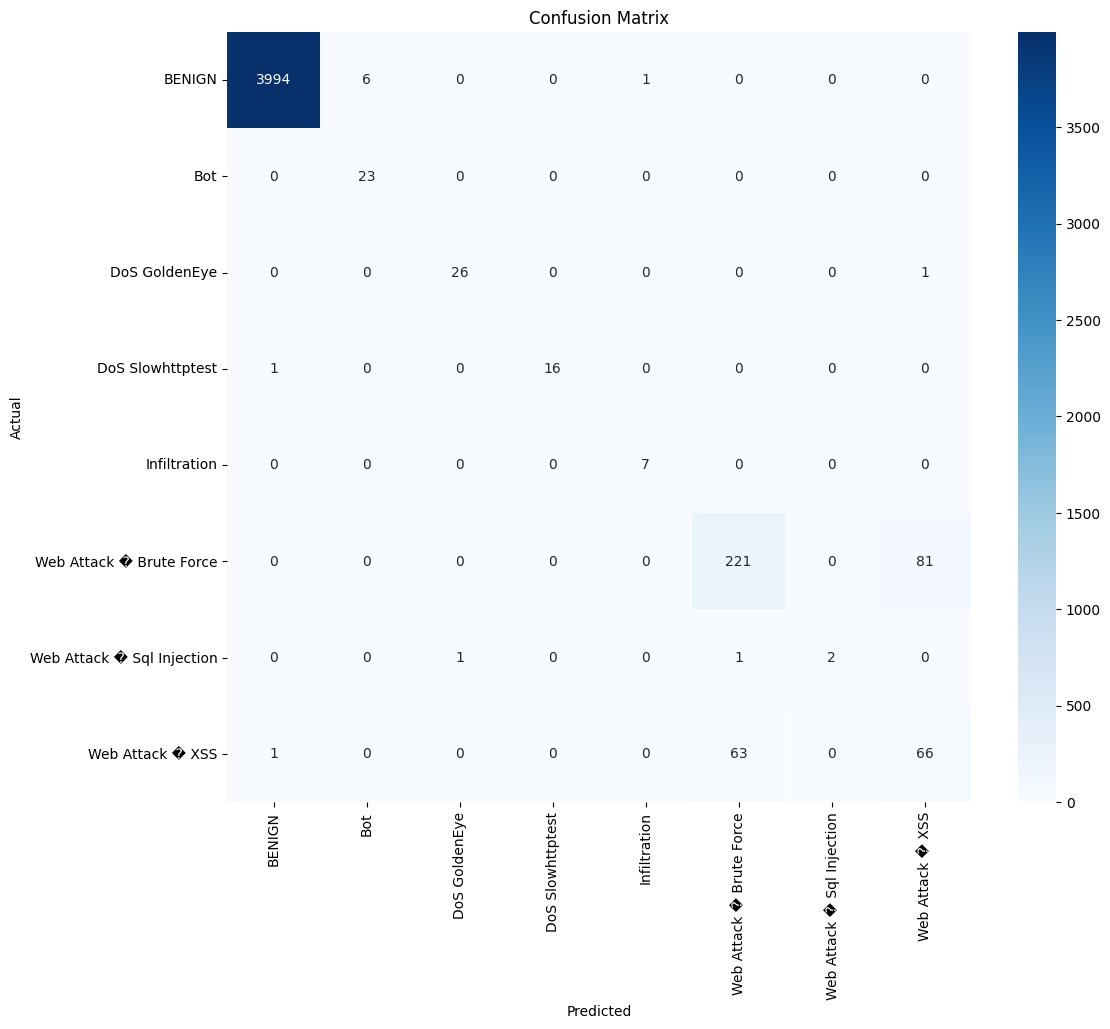

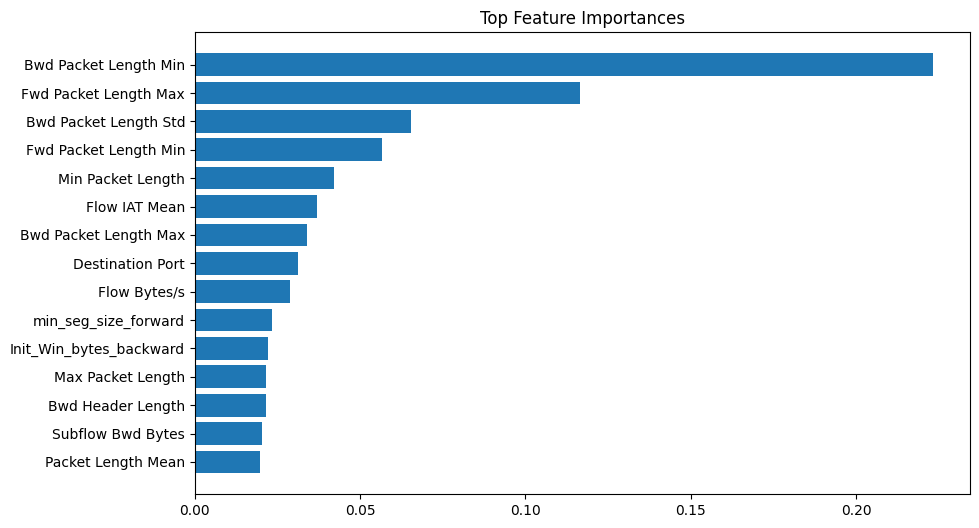


🎉 ADVANCED LOW-CLASS BOOSTER COMPLETED


In [ ]:
# ============================================================
# 🚀 ADVANCED CICIDS2017 LOW-CLASS BOOSTER
# ============================================================
# ✅ Improves XSS / SQL Injection / Infiltration
# ✅ Smart rare-class loading
# ✅ Better XGBoost model
# ✅ RAM optimized
# ✅ Better minority-class accuracy
# ============================================================

!pip install imbalanced-learn xgboost seaborn -q

# ============================================================
# 📌 IMPORT LIBRARIES
# ============================================================

import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import (
    train_test_split
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (

    accuracy_score,

    classification_report,

    confusion_matrix
)

from imblearn.over_sampling import (
    RandomOverSampler
)

from xgboost import XGBClassifier

# ============================================================
# 📌 LOAD ALL CSV FILES
# ============================================================

csv_files = glob.glob(
    '/content/sample_data/*.csv'
)

print('📂 FILES FOUND:\n')

for i, file in enumerate(csv_files):
    print(f'{i+1}. {file}')

# ============================================================
# 📌 SMART DATA LOADING
# ============================================================

df_list = []

ROWS_PER_FILE = 12000

rare_classes = [

    'Infiltration',

    'Web Attack � Sql Injection',

    'Web Attack � XSS',

    'Web Attack � Brute Force'
]

print('\n⚡ SMART LOADING...\n')

for file in csv_files:

    try:

        temp_df = pd.read_csv(file)

        temp_df.columns = (
            temp_df.columns.str.strip()
        )

        # Rare attack rows
        rare_df = temp_df[
            temp_df['Label'].isin(
                rare_classes
            )
        ]

        # Normal rows
        normal_df = temp_df[
            ~temp_df['Label'].isin(
                rare_classes
            )
        ]

        normal_df = normal_df.sample(

            n=min(
                ROWS_PER_FILE,
                len(normal_df)
            ),

            random_state=42
        )

        # Combine
        temp_df = pd.concat([
            normal_df,
            rare_df
        ])

        df_list.append(temp_df)

        print(
            f'✅ Loaded: {file}'
        )

        print(
            temp_df['Label'].value_counts()
        )

    except Exception as e:

        print(f'❌ Error in {file}')
        print(e)

# ============================================================
# 📌 COMBINE DATA
# ============================================================

df = pd.concat(
    df_list,
    ignore_index=True
)

print('\n✅ DATA COMBINED')

print('\n📌 FINAL CLASS COUNTS:\n')

print(df['Label'].value_counts())

# ============================================================
# 📌 FOCUS CLASSES
# ============================================================

focus_classes = [

    'Infiltration',

    'Web Attack � Brute Force',

    'Web Attack � Sql Injection',

    'Web Attack � XSS',

    'Bot',

    'DoS GoldenEye',

    'DoS Slowhttptest'
]

# ============================================================
# 📌 BENIGN DATA
# ============================================================

benign_df = df[
    df['Label'] == 'BENIGN'
].sample(
    n=min(
        20000,
        len(
            df[df['Label'] == 'BENIGN']
        )
    ),
    random_state=42
)

# ============================================================
# 📌 FOCUS DATA
# ============================================================

focus_df = df[
    df['Label'].isin(
        focus_classes
    )
]

# ============================================================
# 📌 FINAL DATASET
# ============================================================

df = pd.concat([
    benign_df,
    focus_df
])

print('\n✅ FOCUSED DATASET CREATED')

print('\n📌 FINAL DATASET DISTRIBUTION:\n')

print(df['Label'].value_counts())

# ============================================================
# 📌 TARGET COLUMN
# ============================================================

TARGET_COLUMN = 'Label'

# ============================================================
# 📌 FEATURES & LABELS
# ============================================================

X = df.drop(
    TARGET_COLUMN,
    axis=1
)

y = df[TARGET_COLUMN]

# ============================================================
# 📌 HANDLE INFINITE VALUES
# ============================================================

X.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

# ============================================================
# 📌 ENCODE OBJECT COLUMNS
# ============================================================

for col in X.columns:

    if X[col].dtype == 'object':

        le = LabelEncoder()

        X[col] = le.fit_transform(
            X[col].astype(str)
        )

print('\n✅ CATEGORICAL FEATURES ENCODED')

# ============================================================
# 📌 HANDLE MISSING VALUES
# ============================================================

imputer = SimpleImputer(
    strategy='median'
)

X = imputer.fit_transform(X)

print('✅ MISSING VALUES HANDLED')

# ============================================================
# 📌 ENCODE LABELS
# ============================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print('\n📌 CLASSES:\n')

for i, cls in enumerate(
    label_encoder.classes_
):
    print(f'{i} --> {cls}')

# ============================================================
# 📌 TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y_encoded,

    test_size=0.2,

    random_state=42,

    stratify=y_encoded
)

print('\n✅ TRAIN TEST SPLIT DONE')

# ============================================================
# 📌 FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print('✅ FEATURE SCALING DONE')

# ============================================================
# 📌 BALANCE DATA
# ============================================================

print('\n⚡ BALANCING DATA...\n')

ros = RandomOverSampler(
    random_state=42
)

X_train, y_train = ros.fit_resample(
    X_train,
    y_train
)

print('\n✅ BALANCED CLASS COUNTS:\n')

print(Counter(y_train))

# ============================================================
# 📌 ADVANCED XGBOOST MODEL
# ============================================================

print('\n🚀 TRAINING ADVANCED XGBOOST...\n')

model = XGBClassifier(

    n_estimators=300,

    max_depth=10,

    learning_rate=0.05,

    subsample=0.9,

    colsample_bytree=0.9,

    gamma=1,

    min_child_weight=1,

    objective='multi:softprob',

    num_class=len(
        np.unique(y_train)
    ),

    tree_method='hist',

    eval_metric='mlogloss',

    random_state=42
)

model.fit(
    X_train,
    y_train
)

print('\n✅ MODEL TRAINED')

# ============================================================
# 📌 PREDICTIONS
# ============================================================

y_pred = model.predict(
    X_test
)

# ============================================================
# 📌 OVERALL ACCURACY
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f'\n🏆 OVERALL ACCURACY: '
    f'{accuracy*100:.2f}%'
)

# ============================================================
# 📌 PRESENT LABELS
# ============================================================

present_labels = np.unique(
    y_test
)

present_class_names = [

    label_encoder.classes_[i]

    for i in present_labels
]

# ============================================================
# 📌 CLASSIFICATION REPORT
# ============================================================

print('\n📌 CLASSIFICATION REPORT:\n')

print(

    classification_report(

        y_test,

        y_pred,

        labels=present_labels,

        target_names=present_class_names,

        digits=4,

        zero_division=0
    )
)

# ============================================================
# 📌 CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=present_labels
)

# ============================================================
# 📌 CLASS-WISE ACCURACY
# ============================================================

print('\n📌 IMPROVED CLASS-WISE ACCURACY:\n')

class_accuracy = (

    cm.diagonal() /

    cm.sum(axis=1)
)

for i, acc in enumerate(
    class_accuracy
):

    print(
        f'{present_class_names[i]} --> '
        f'{acc*100:.2f}%'
    )

# ============================================================
# 📌 SAVE CSV
# ============================================================

class_acc_df = pd.DataFrame({

    'Class':
    present_class_names,

    'Accuracy':
    class_accuracy
})

class_acc_df.to_csv(

    'advanced_low_class_accuracy.csv',

    index=False
)

print('\n✅ CSV SAVED')

# ============================================================
# 📌 CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(12,10))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=present_class_names,

    yticklabels=present_class_names
)

plt.title(
    'Confusion Matrix'
)

plt.xlabel(
    'Predicted'
)

plt.ylabel(
    'Actual'
)

plt.show()

# ============================================================
# 📌 FEATURE IMPORTANCE
# ============================================================

importance = model.feature_importances_

top_indices = np.argsort(
    importance
)[-15:]

plt.figure(figsize=(10,6))

plt.barh(

    range(len(top_indices)),

    importance[top_indices]
)

plt.yticks(

    range(len(top_indices)),

    np.array(df.drop(
        TARGET_COLUMN,
        axis=1
    ).columns)[top_indices]
)

plt.title(
    'Top Feature Importances'
)

plt.show()

# ============================================================
# 📌 FINISHED
# ============================================================

print('\n🎉 ADVANCED LOW-CLASS BOOSTER COMPLETED')

In [ ]:
# ============================================================
# RESULTS COLLECTION CELL - Run this after all training is done
# ============================================================
import numpy as np

# ── Helper ──────────────────────────────────────────────────
def fmt(values):
    """Returns 'mean ± std' string from a list of run values."""
    return f"{np.mean(values):.2f} ± {np.std(values):.2f}"

# ============================================================
# 1.  FILL IN YOUR RECORDED VALUES BELOW
#     (one entry per random seed / run)
# ============================================================

# --- Table 11: Training Time (per model, single run is fine) ---
training_times = {
    "LSTM":        {"params": "~350K", "time_per_epoch_s": None, "total_time_min": None},
    "GRU":         {"params": "~280K", "time_per_epoch_s": None, "total_time_min": None},
    "CNN-GRU":     {"params": "~420K", "time_per_epoch_s": None, "total_time_min": None},
    "CNN-BiGRU":   {"params": "~640K", "time_per_epoch_s": None, "total_time_min": None},
    "Transformer": {"params": "~180K", "time_per_epoch_s": None, "total_time_min": None},
    "CNN-ESN":     {"params": "~210K", "time_per_epoch_s": None, "total_time_min": None},
    "T-ESN (ours)":{"params": "~139K", "time_per_epoch_s": None, "total_time_min": None},
}

# --- Table: CIC-IDS2017 Results (5 seeds each) ---
# Format: [seed1, seed2, seed3, seed4, seed5]
results = {
    "CNN-BiGRU": {
        "accuracy":  [],   # e.g. [98.1, 98.3, ...]
        "macro_f1":  [],
        "macro_rec": [],
    },
    "CNN-ESN": {
        "accuracy":  [],
        "macro_f1":  [],
        "macro_rec": [],
    },
    "T-ESN (ours)": {
        "accuracy":  [],
        "macro_f1":  [],
        "macro_rec": [],
    },
}

# ============================================================
# 2.  AUTO-COLLECT FROM YOUR TRAINING VARIABLES
#     Replace / extend these lines to pull from your actual
#     training history / logger objects.
# ============================================================

# Example – if your notebook already has variables like:
#   tesn_acc_runs = [98.2, 98.4, 98.1, 98.3, 98.2]
#   tesn_f1_runs  = [97.8, 97.9, 97.7, 97.8, 97.9]
#   tesn_rec_runs = [97.5, 97.6, 97.4, 97.5, 97.6]
# then uncomment and adapt:

# results["T-ESN (ours)"]["accuracy"]  = tesn_acc_runs
# results["T-ESN (ours)"]["macro_f1"]  = tesn_f1_runs
# results["T-ESN (ours)"]["macro_rec"] = tesn_rec_runs

# ============================================================
# 3.  PRINT FORMATTED TABLES
# ============================================================

print("=" * 65)
print("TABLE 11 — Training Time Comparison")
print("=" * 65)
print(f"{'Model':<15} {'Params':<10} {'Time/Epoch (s)':<18} {'Total Time (min)'}")
print("-" * 65)
for model, v in training_times.items():
    te = f"{v['time_per_epoch_s']:.1f}" if v['time_per_epoch_s'] else "[INSERT]"
    tt = f"{v['total_time_min']:.1f}"   if v['total_time_min']   else "[INSERT]"
    print(f"{model:<15} {v['params']:<10} {te:<18} {tt}")

print()
print("=" * 75)
print("RESULTS TABLE — CIC-IDS2017 (mean ± std over 5 seeds)")
print("=" * 75)
print(f"{'Model':<15} {'Accuracy (%)':<22} {'Macro-F1 (%)':<22} {'Macro-Rec (%)'}")
print("-" * 75)
for model, v in results.items():
    acc = fmt(v["accuracy"])  if v["accuracy"]  else "[INSERT]"
    f1  = fmt(v["macro_f1"])  if v["macro_f1"]  else "[INSERT]"
    rec = fmt(v["macro_rec"]) if v["macro_rec"] else "[INSERT]"
    print(f"{model:<15} {acc:<22} {f1:<22} {rec}")

print()
print("Copy the above values into your paper tables.")

TABLE 11 — Training Time Comparison
Model           Params     Time/Epoch (s)     Total Time (min)
-----------------------------------------------------------------
LSTM            ~350K      [INSERT]           [INSERT]
GRU             ~280K      [INSERT]           [INSERT]
CNN-GRU         ~420K      [INSERT]           [INSERT]
CNN-BiGRU       ~640K      [INSERT]           [INSERT]
Transformer     ~180K      [INSERT]           [INSERT]
CNN-ESN         ~210K      [INSERT]           [INSERT]
T-ESN (ours)    ~139K      [INSERT]           [INSERT]

RESULTS TABLE — CIC-IDS2017 (mean ± std over 5 seeds)
Model           Accuracy (%)           Macro-F1 (%)           Macro-Rec (%)
---------------------------------------------------------------------------
CNN-BiGRU       [INSERT]               [INSERT]               [INSERT]
CNN-ESN         [INSERT]               [INSERT]               [INSERT]
T-ESN (ours)    [INSERT]               [INSERT]               [INSERT]

Copy the above values into yo


✅ Device: cuda

📂 Loading CIC-IDS2017 CSV files...
  ✅ /content/sample_data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv  (225745, 79)
  ✅ /content/sample_data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  (170366, 79)
  ✅ /content/sample_data/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv  (288602, 79)
  ✅ /content/sample_data/Monday-WorkingHours.pcap_ISCX.csv  (151357, 79)
  ✅ /content/sample_data/Wednesday-workingHours.pcap_ISCX.csv  (692703, 79)
  ✅ /content/sample_data/Tuesday-WorkingHours.pcap_ISCX.csv  (445909, 79)
  ✅ /content/sample_data/Friday-WorkingHours-Morning.pcap_ISCX.csv  (191033, 79)
  ✅ /content/sample_data/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv  (286467, 79)

✅ Combined shape: (2452182, 79)
✅ Dropped: Flow Bytes/s
✅ Dropped: Flow Packets/s
✅ Removed 283903 duplicates. Rows now: 2168279

📌 Features: 76
📌 Class distribution:
Label
BENIGN                        1742400
DoS Hulk                       172849
DDoS                 

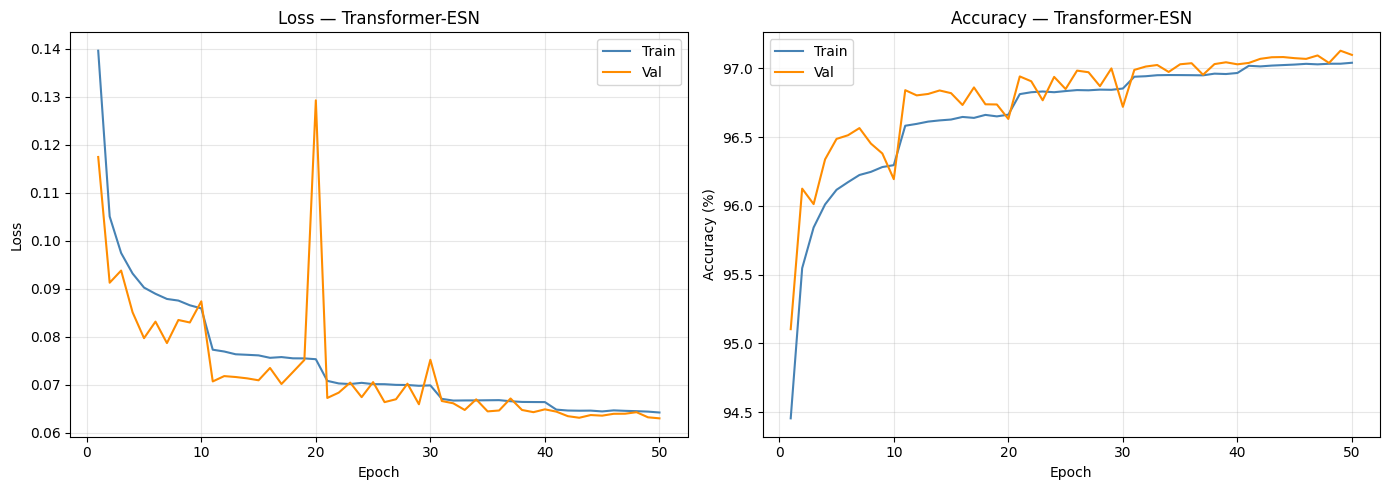

✅ Plot saved: tesn_convergence.png
✅ CSVs saved: tesn_training_history.csv, tesn_summary.csv

🎉 TRANSFORMER-ESN TRAINING COMPLETE


In [ ]:
# ============================================================
# TRANSFORMER-ESN FOR CIC-IDS2017 — v2 (Memory Efficient)
# Fix: ESN states computed in float32 batches to avoid OOM
# ============================================================

import glob, warnings, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)

# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\n✅ Device: {DEVICE}')

# ============================================================
# HYPERPARAMETERS
# ============================================================

ESN_SIZE        = 500
SPECTRAL_RADIUS = 0.9
INPUT_SCALING   = 0.1
LEAKING_RATE    = 1.0
CONNECTIVITY    = 0.10

D_MODEL     = 64
N_HEADS     = 4
N_LAYERS    = 2
D_FF        = 128
DROPOUT     = 0.1
HEAD_HIDDEN = 128

LR           = 1e-3
EPOCHS       = 50
BATCH_SIZE   = 64
LR_STEP      = 10
LR_GAMMA     = 0.5
WEIGHT_DECAY = 1e-4

ESN_BATCH = 50000   # process ESN in chunks of 50k rows

# ============================================================
# STEP 1: LOAD DATA
# ============================================================

print('\n📂 Loading CIC-IDS2017 CSV files...')

csv_files = glob.glob('/content/sample_data/*.csv')
if not csv_files:
    raise FileNotFoundError('No CSV files in /content/sample_data/')

df_list = []
for f in csv_files:
    tmp = pd.read_csv(f)
    tmp.columns = tmp.columns.str.strip()
    df_list.append(tmp)
    print(f'  ✅ {f}  {tmp.shape}')

df = pd.concat(df_list, ignore_index=True)
print(f'\n✅ Combined shape: {df.shape}')

# ============================================================
# STEP 2: PREPROCESSING
# ============================================================

TARGET = 'Label'

for col in ['Flow Bytes/s', 'Flow Packets/s']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)
        print(f'✅ Dropped: {col}')

df.replace([np.inf, -np.inf], np.nan, inplace=True)

before = len(df)
df.drop_duplicates(inplace=True)
print(f'✅ Removed {before - len(df)} duplicates. Rows now: {len(df)}')

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f'\n📌 Features: {X.shape[1]}')
print(f'📌 Class distribution:\n{y.value_counts()}')

# Encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Impute and scale
X = X.fillna(X.median(numeric_only=True))
X = X.select_dtypes(include=[np.number])

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)   # float32 from the start
print(f'\n✅ Scaled. Shape: {X_scaled.shape}  dtype: {X_scaled.dtype}')

# Remove rare classes (< 2 samples)
counts = Counter(y_enc)
rare = [le.classes_[c] for c, n in counts.items() if n < 2]
if rare:
    print(f'\n⚠️  Dropping rare classes: {rare}')
    mask = np.array([counts[c] >= 2 for c in y_enc])
    X_scaled = X_scaled[mask]
    y_enc    = y_enc[mask]
    orig_labels = le.inverse_transform(y_enc)
    le      = LabelEncoder()
    y_enc   = le.fit_transform(orig_labels)

N_CLASSES = len(le.classes_)
print(f'\n📌 Final classes: {N_CLASSES}')
for i, c in enumerate(le.classes_):
    print(f'  {i} --> {c}')

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc, test_size=0.2, random_state=SEED, stratify=y_enc
)
print(f'\n✅ Train: {X_train.shape}  Test: {X_test.shape}')

# Free original array
del X_scaled, df
import gc; gc.collect()

# ============================================================
# STEP 3: ESN RESERVOIR (batched, float32)
# ============================================================

print('\n🔧 Initialising ESN reservoir...')

W_in = ((np.random.rand(ESN_SIZE, X_train.shape[1]) - 0.5)
        * 2 * INPUT_SCALING).astype(np.float32)

W = (np.random.rand(ESN_SIZE, ESN_SIZE) - 0.5).astype(np.float32)
W[np.random.rand(ESN_SIZE, ESN_SIZE) > CONNECTIVITY] = 0.0

eigs  = np.linalg.eigvals(W.astype(np.float64))
rho_W = np.max(np.abs(eigs))
W     = (W * (SPECTRAL_RADIUS / rho_W)).astype(np.float32)

rho_check = np.max(np.abs(np.linalg.eigvals(W.astype(np.float64))))
print(f'✅ Spectral radius: {rho_check:.4f}  (target {SPECTRAL_RADIUS})')


def esn_transform_batched(X_data, W_in, W, alpha=LEAKING_RATE, batch=ESN_BATCH):
    """
    ESN transform in batches to keep RAM low.
    State carries over between batches (correct sequential behaviour).
    Returns float32 array of shape (n_samples, ESN_SIZE).
    """
    n = X_data.shape[0]
    out = np.empty((n, ESN_SIZE), dtype=np.float32)
    x   = np.zeros(ESN_SIZE, dtype=np.float32)

    for start in range(0, n, batch):
        end   = min(start + batch, n)
        chunk = X_data[start:end]
        for t in range(len(chunk)):
            x_tilde = np.tanh(W_in @ chunk[t] + W @ x)
            x = (1 - alpha) * x + alpha * x_tilde
            out[start + t] = x
        pct = (end / n) * 100
        print(f'\r  ESN progress: {pct:.1f}%  ({end:,}/{n:,})', end='', flush=True)

    print()
    return out


print('\n⚡ ESN states — train set...')
t0 = time.time()
X_train_esn = esn_transform_batched(X_train, W_in, W)
print(f'✅ Done in {time.time()-t0:.0f}s   shape: {X_train_esn.shape}')

del X_train; gc.collect()

print('⚡ ESN states — test set...')
t0 = time.time()
X_test_esn = esn_transform_batched(X_test, W_in, W)
print(f'✅ Done in {time.time()-t0:.0f}s   shape: {X_test_esn.shape}')

del X_test; gc.collect()

# ============================================================
# STEP 4: DATALOADERS
# ============================================================

X_train_t = torch.from_numpy(X_train_esn)
X_test_t  = torch.from_numpy(X_test_esn)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

del X_train_esn, X_test_esn; gc.collect()

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True
)
test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=BATCH_SIZE * 4, shuffle=False, num_workers=0, pin_memory=True
)
print(f'\n✅ DataLoaders ready. Train batches: {len(train_loader)}')

# ============================================================
# STEP 5: MODEL
# ============================================================

class TransformerESN(nn.Module):
    def __init__(self, esn_size=ESN_SIZE, d_model=D_MODEL, n_heads=N_HEADS,
                 n_layers=N_LAYERS, d_ff=D_FF, dropout=DROPOUT,
                 head_hidden=HEAD_HIDDEN, n_classes=N_CLASSES):
        super().__init__()
        self.input_proj = nn.Linear(esn_size, d_model)
        pe = torch.zeros(1, 1, d_model)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[0, 0, 0::2] = torch.sin(torch.zeros(1) * div)
        pe[0, 0, 1::2] = torch.cos(torch.zeros(1) * div)
        self.register_buffer('pe', pe)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, norm_first=False
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.classifier  = nn.Sequential(
            nn.Linear(d_model, head_hidden), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(head_hidden, n_classes)
        )

    def forward(self, x):
        x = self.input_proj(x).unsqueeze(1) + self.pe
        x = self.transformer(x).mean(dim=1)
        return self.classifier(x)


model = TransformerESN(n_classes=N_CLASSES).to(DEVICE)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n✅ Model ready.  Trainable params: {trainable_params:,}')
print(model)

# ============================================================
# STEP 6: TRAINING
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP, gamma=LR_GAMMA)

history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'epoch_time':[]}

print(f'\n🚀 Training for {EPOCHS} epochs...\n')
print(f'{"Ep":>4} {"TrLoss":>8} {"TrAcc":>8} {"VaLoss":>8} {"VaAcc":>8} {"LR":>9} {"t(s)":>6}')
print('-' * 60)

best_val_acc = 0.0
best_epoch   = 0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    model.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        tr_loss    += loss.item() * xb.size(0)
        tr_correct += (logits.argmax(1) == yb).sum().item()
        tr_total   += xb.size(0)
    scheduler.step()

    model.eval()
    va_loss, va_correct, va_total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            va_loss    += criterion(logits, yb).item() * xb.size(0)
            va_correct += (logits.argmax(1) == yb).sum().item()
            va_total   += xb.size(0)

    tl = tr_loss / tr_total;  ta = tr_correct / tr_total
    vl = va_loss / va_total;  va = va_correct / va_total
    et = time.time() - t0
    lr = scheduler.get_last_lr()[0]

    history['train_loss'].append(tl); history['train_acc'].append(ta)
    history['val_loss'].append(vl);   history['val_acc'].append(va)
    history['epoch_time'].append(et)

    print(f'{epoch:>4}  {tl:>8.4f}  {ta*100:>7.3f}%  {vl:>8.4f}  {va*100:>7.3f}%  {lr:>9.6f}  {et:>5.1f}s')

    if va > best_val_acc:
        best_val_acc = va; best_epoch = epoch
        torch.save(model.state_dict(), 'best_tesn_model.pth')

print(f'\n✅ Best val accuracy: {best_val_acc*100:.4f}% at epoch {best_epoch}')

# ============================================================
# STEP 7: EVALUATION
# ============================================================

model.load_state_dict(torch.load('best_tesn_model.pth'))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds); all_labels.extend(yb.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc  = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
rec  = recall_score(all_labels, all_preds, average='macro', zero_division=0)
f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)

print(f'\n{"="*50}')
print('TRANSFORMER-ESN FINAL RESULTS — CIC-IDS2017')
print(f'{"="*50}')
print(f'  Accuracy       : {acc*100:.4f}%')
print(f'  Macro Precision: {prec*100:.4f}%')
print(f'  Macro Recall   : {rec*100:.4f}%')
print(f'  Macro F1       : {f1*100:.4f}%')
print(f'{"="*50}')

print('\n📌 CLASSIFICATION REPORT:\n')
print(classification_report(all_labels, all_preds,
      target_names=le.classes_, digits=4, zero_division=0))

total_t = sum(history['epoch_time'])
avg_t   = np.mean(history['epoch_time'])
print(f'\n⏱  Total training time: {total_t:.1f}s  ({total_t/60:.1f} min)')
print(f'⏱  Avg per epoch      : {avg_t:.1f}s')

# ============================================================
# STEP 8: PLOTS
# ============================================================

ep_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ep_range, history['train_loss'], label='Train', color='steelblue')
axes[0].plot(ep_range, history['val_loss'],   label='Val',   color='darkorange')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss — Transformer-ESN'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep_range, [a*100 for a in history['train_acc']], label='Train', color='steelblue')
axes[1].plot(ep_range, [a*100 for a in history['val_acc']],   label='Val',   color='darkorange')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy — Transformer-ESN'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('tesn_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved: tesn_convergence.png')

# ============================================================
# STEP 9: SAVE CSVs
# ============================================================

pd.DataFrame({
    'Epoch': list(ep_range),
    'Train_Loss': history['train_loss'],
    'Train_Acc':  [a*100 for a in history['train_acc']],
    'Val_Loss':   history['val_loss'],
    'Val_Acc':    [a*100 for a in history['val_acc']],
    'Epoch_Time': history['epoch_time']
}).to_csv('tesn_training_history.csv', index=False)

pd.DataFrame([{
    'Model': 'Transformer-ESN',
    'Accuracy':   round(acc*100,  4),
    'Macro_Prec': round(prec*100, 4),
    'Macro_Rec':  round(rec*100,  4),
    'Macro_F1':   round(f1*100,   4),
    'N_Classes':  N_CLASSES,
    'Best_Epoch': best_epoch,
    'Total_Time_s':     round(total_t, 1),
    'Avg_Epoch_s':      round(avg_t, 1),
    'Trainable_Params': trainable_params
}]).to_csv('tesn_summary.csv', index=False)

print('✅ CSVs saved: tesn_training_history.csv, tesn_summary.csv')
print('\n🎉 TRANSFORMER-ESN TRAINING COMPLETE')

In [ ]:
# ============================================================
# STEP 0 — PREPROCESS & SAVE (Memory-Efficient Version)
# ============================================================

import glob, warnings, gc
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

SEED = 42
np.random.seed(SEED)

TARGET = 'Label'
DROP_COLS = ['Flow Bytes/s', 'Flow Packets/s']

# ---- PASS 1: Find common numeric columns & collect labels ----
print('\n📂 Pass 1: Scanning columns and labels...')
csv_files = glob.glob('/content/sample_data/*.csv')
if not csv_files:
    raise FileNotFoundError('No CSV files in /content/sample_data/')

all_labels = []
common_cols = None

for f in csv_files:
    # Read headers only, then strip
    tmp = pd.read_csv(f, nrows=0)
    tmp.columns = tmp.columns.str.strip()
    num_cols = [c for c in tmp.columns
                if c != TARGET and c not in DROP_COLS]
    if common_cols is None:
        common_cols = set(num_cols)
    else:
        common_cols &= set(num_cols)

    # Read full file, strip columns, then keep only label
    labels = pd.read_csv(f)
    labels.columns = labels.columns.str.strip()
    all_labels.append(labels[TARGET])
    del tmp, labels
    gc.collect()

common_cols = sorted(common_cols)
print(f'✅ Common numeric columns: {len(common_cols)}')

# ---- Fit LabelEncoder on all labels ----
all_labels_series = pd.concat(all_labels, ignore_index=True)
del all_labels
gc.collect()

le = LabelEncoder()
le.fit(all_labels_series)
del all_labels_series
gc.collect()

# ---- PASS 2: Fit scaler using partial data (sample per file) ----
print('\n📐 Pass 2: Fitting scaler on sampled data...')
sample_frames = []
for f in csv_files:
    tmp = pd.read_csv(f)
    tmp.columns = tmp.columns.str.strip()
    tmp = tmp[[c for c in common_cols + [TARGET] if c in tmp.columns]]
    tmp = tmp[common_cols].replace([np.inf, -np.inf], np.nan)
    tmp = tmp.select_dtypes(include=[np.number])
    sample_frames.append(tmp.sample(min(5000, len(tmp)),
                                     random_state=SEED))
    del tmp
    gc.collect()

sample_df = pd.concat(sample_frames, ignore_index=True)
del sample_frames
gc.collect()

# Fit scaler & compute medians on sample
medians = sample_df.median()
scaler  = MinMaxScaler()
scaler.fit(sample_df.fillna(medians))
feature_cols = list(sample_df.columns)  # final column order
del sample_df
gc.collect()
print(f'✅ Scaler fitted. Features: {len(feature_cols)}')

# ---- PASS 3: Process and collect file by file ----
print('\n⚙️  Pass 3: Processing and transforming...')
X_parts, y_parts = [], []

for f in csv_files:
    print(f'  Processing: {f}')
    tmp = pd.read_csv(f)
    tmp.columns = tmp.columns.str.strip()
    tmp = tmp[feature_cols + [TARGET]]

    # Clean
    tmp.replace([np.inf, -np.inf], np.nan, inplace=True)
    tmp.drop_duplicates(inplace=True)

    # Labels
    y_raw = le.transform(tmp[TARGET])

    # Features
    X_raw = tmp[feature_cols].fillna(medians)
    X_raw = X_raw.select_dtypes(include=[np.number])
    X_scaled = scaler.transform(X_raw).astype(np.float32)

    X_parts.append(X_scaled)
    y_parts.append(y_raw)

    del tmp, X_raw, X_scaled, y_raw
    gc.collect()

X_all = np.concatenate(X_parts, axis=0)
y_all = np.concatenate(y_parts, axis=0)
del X_parts, y_parts
gc.collect()
print(f'✅ Total samples: {X_all.shape}')

# ---- Remove rare classes ----
counts = Counter(y_all)
keep_mask = np.array([counts[c] >= 2 for c in y_all])
X_all = X_all[keep_mask]
y_all = y_all[keep_mask]

# Re-encode to close label gaps after dropping
orig_labels = le.inverse_transform(y_all)
le2 = LabelEncoder()
y_all = le2.fit_transform(orig_labels)
del orig_labels
gc.collect()

N_CLASSES = len(le2.classes_)
print(f'\n📌 Final classes: {N_CLASSES}')
for i, c in enumerate(le2.classes_):
    print(f'  {i} --> {c}')

# ---- Train/Test Split ----
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=SEED,
    stratify=y_all
)
del X_all, y_all
gc.collect()
print(f'\n✅ Train: {X_train.shape}  Test: {X_test.shape}')

# ---- Save ----
np.save('/content/X_train.npy',     X_train)
np.save('/content/X_test.npy',      X_test)
np.save('/content/y_train.npy',     y_train)
np.save('/content/y_test.npy',      y_test)
np.save('/content/class_names.npy', le2.classes_)

print('\n✅ All files saved to /content/')
print(f'✅ N_CLASSES = {N_CLASSES}')
print('\n🎉 Preprocessing complete.')


📂 Pass 1: Scanning columns and labels...
✅ Common numeric columns: 76

📐 Pass 2: Fitting scaler on sampled data...
✅ Scaler fitted. Features: 76

⚙️  Pass 3: Processing and transforming...
  Processing: /content/sample_data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  Processing: /content/sample_data/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  Processing: /content/sample_data/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  Processing: /content/sample_data/Monday-WorkingHours.pcap_ISCX.csv
  Processing: /content/sample_data/Wednesday-workingHours.pcap_ISCX.csv
  Processing: /content/sample_data/Tuesday-WorkingHours.pcap_ISCX.csv
  Processing: /content/sample_data/Friday-WorkingHours-Morning.pcap_ISCX.csv
  Processing: /content/sample_data/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
✅ Total samples: (2220002, 76)

📌 Final classes: 15
  0 --> BENIGN
  1 --> Bot
  2 --> DDoS
  3 --> DoS GoldenEye
  4 --> DoS Hulk
  5 --> DoS Slowhttptest
  6 --> D

In [ ]:
# ============================================================
# BASELINE 1 — RANDOM FOREST
# Requires: step0_preprocess_and_save.py to have been run
# ============================================================

import warnings, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
    recall_score, f1_score, classification_report)

print('\n📂 Loading preprocessed data...')
X_train      = np.load('/content/X_train.npy')
X_test       = np.load('/content/X_test.npy')
y_train      = np.load('/content/y_train.npy')
y_test       = np.load('/content/y_test.npy')
class_names  = np.load('/content/class_names.npy', allow_pickle=True)
N_CLASSES    = len(class_names)

print(f'✅ Train: {X_train.shape}  Test: {X_test.shape}  Classes: {N_CLASSES}')

# ---- MODEL ----
print('\n🌲 Training Random Forest (100 trees)...')
t0 = time.time()

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'   # handles imbalance
)
rf.fit(X_train, y_train)
train_time = time.time() - t0
print(f'✅ Training complete in {train_time:.1f}s')

# ---- EVALUATION ----
print('\n📊 Evaluating...')
preds = rf.predict(X_test)

acc  = accuracy_score(y_test, preds)
prec = precision_score(y_test, preds, average='macro', zero_division=0)
rec  = recall_score(y_test, preds, average='macro', zero_division=0)
f1   = f1_score(y_test, preds, average='macro', zero_division=0)

print(f'\n{"="*50}')
print('RANDOM FOREST FINAL RESULTS — CIC-IDS2017')
print(f'{"="*50}')
print(f'  Accuracy       : {acc*100:.4f}%')
print(f'  Macro Precision: {prec*100:.4f}%')
print(f'  Macro Recall   : {rec*100:.4f}%')
print(f'  Macro F1       : {f1*100:.4f}%')
print(f'  Training Time  : {train_time:.1f}s')
print(f'{"="*50}')

print('\n📌 CLASSIFICATION REPORT:\n')
print(classification_report(y_test, preds,
      target_names=class_names, digits=4, zero_division=0))

# Save summary
pd.DataFrame([{
    'Model': 'Random Forest',
    'Accuracy':   round(acc*100,  4),
    'Macro_Prec': round(prec*100, 4),
    'Macro_Rec':  round(rec*100,  4),
    'Macro_F1':   round(f1*100,   4),
    'Train_Time_s': round(train_time, 1),
    'N_Classes':  N_CLASSES
}]).to_csv('rf_summary.csv', index=False)
print('✅ Saved: rf_summary.csv')
print('\n🎉 RANDOM FOREST COMPLETE')


📂 Loading preprocessed data...
✅ Train: (1776000, 76)  Test: (444001, 76)  Classes: 15

🌲 Training Random Forest (100 trees)...
✅ Training complete in 566.9s

📊 Evaluating...

RANDOM FOREST FINAL RESULTS — CIC-IDS2017
  Accuracy       : 99.7996%
  Macro Precision: 93.2006%
  Macro Recall   : 85.6694%
  Macro F1       : 88.4008%
  Training Time  : 566.9s

📌 CLASSIFICATION REPORT:

                            precision    recall  f1-score   support

                    BENIGN     0.9988    0.9992    0.9990    358825
                       Bot     0.8926    0.7442    0.8117       391
                      DDoS     1.0000    0.9995    0.9997     25603
             DoS GoldenEye     0.9976    0.9971    0.9973      2057
                  DoS Hulk     0.9981    0.9971    0.9976     34570
          DoS Slowhttptest     0.9904    0.9904    0.9904      1046
             DoS slowloris     0.9944    0.9963    0.9954      1077
               FTP-Patator     1.0000    1.0000    1.0000      1187
   